# MSE score sucks
- both MSE based - DSDF and deformation of template in SDF report low scores in affine and deformed (16 %)
- this is weird since it shouldnt perform worse than CentroidLoss (73 % aff, 45 % def )
- debug on affine, if we can regress at least the shift and rot on one sample by grad descent

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from constraints import get_data_folder
from constraints.computers.loss_terms import RegistrationDSDFMSETerm
from constraints.datatools.datasets import CachedArtificalDataset
from constraints.transforms.transformers import RigidTransformer
from constraints.types import LossInput, RigidParams, TransformSpec

DATA = get_data_folder() / "artificial" / "custom"
TRN_FOLDER = DATA / "affine" / "trn"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)

transformer = RigidTransformer().to(DEVICE)
trn_dataset = CachedArtificalDataset(
    TRN_FOLDER,
    sdf_mode="kornia",
    return_transform=True,
    return_template_sdf=True,
 )

In [4]:
sample = trn_dataset[0]
template = sample["template"].unsqueeze(0).to(DEVICE, dtype=torch.float32)
target_mask = sample["mask"].unsqueeze(0).to(DEVICE, dtype=torch.float32)
target_sdf = sample["sdf"].unsqueeze(0).to(DEVICE, dtype=torch.float32)
ground_truth_matrix = sample["transform"]

print(f"template: {tuple(template.shape)}, target: {tuple(target_mask.shape)}")
print(f"target SDF range: [{target_sdf.min().item():.3f}, {target_sdf.max().item():.3f}]")
print("stored affine matrix:\n", ground_truth_matrix)
assert template.shape == target_mask.shape
assert target_sdf.shape[1] == template.shape[1] - 1

template: (1, 4, 256, 256), target: (1, 4, 256, 256)
target SDF range: [-8.590, 123.833]
stored affine matrix:
 tensor([[ 0.3338, -0.9426,  0.4932],
        [ 0.9426,  0.3338,  0.0589]])


In [5]:
from constraints.utils import signed_distance_kornia_differentiable

recomputed_target_sdf = signed_distance_kornia_differentiable(target_mask[:, 1:])
sdf_difference = recomputed_target_sdf - target_sdf
print(f"stored vs recomputed SDF MSE: {sdf_difference.square().mean().item():.6g}")
print(f"stored vs recomputed max abs error: {sdf_difference.abs().max().item():.6g}")
assert torch.allclose(recomputed_target_sdf, target_sdf, atol=1e-5), (
    "The stored target SDF does not match the differentiable SDF used by "
    "RegistrationDSDFMSETerm."
 )

stored vs recomputed SDF MSE: 5.12125e-17
stored vs recomputed max abs error: 4.76837e-07


loss at stored transform - DSDF: 3.69555e-11, mask MSE: 1.80412e-13


dsdf: loss 5.49396 -> 0.107761; gradient available: True; grad norm at step 0: 732.31; params: angle=1.125, dx=0.497, dy=0.005
mask_mse: loss 0.149941 -> 0.000209475; gradient available: True; grad norm at step 0: 0.993907; params: angle=1.230, dx=0.493, dy=0.061
stored parameters: angle=1.230, dx=0.493, dy=0.059


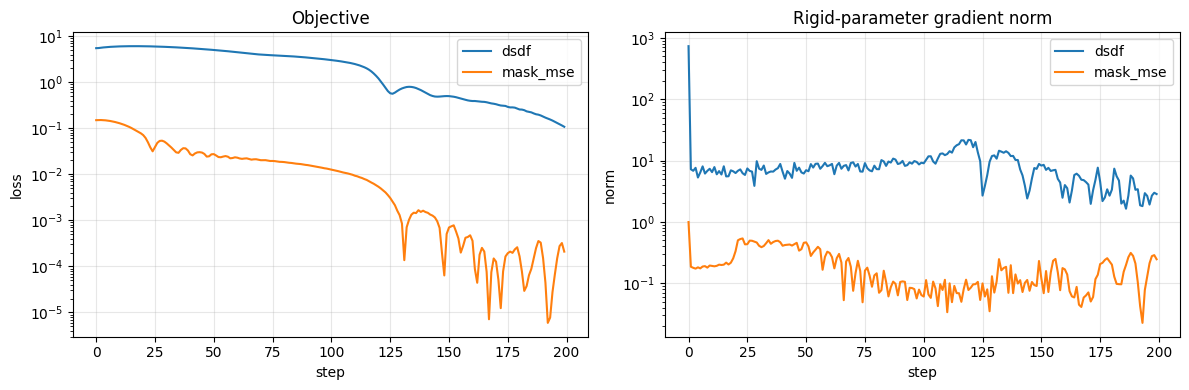

In [13]:
import importlib
import constraints.computers.loss_terms as loss_terms
from constraints.utils import mat2params

importlib.reload(loss_terms)
dsdf_term = loss_terms.RegistrationDSDFMSETerm().to(DEVICE)
ground_truth_params = mat2params(ground_truth_matrix.to(DEVICE, dtype=torch.float32))
known_warp = transformer(template, TransformSpec(rigid=ground_truth_params)).warped_template
known_dsdf_loss = dsdf_term(
    LossInput(
        warped_template=known_warp,
        gt_mask=target_mask,
        gt_mask_sdf=target_sdf,
    )
 )
known_mask_loss = torch.nn.functional.mse_loss(known_warp[:, 1:], target_mask[:, 1:])
print(f"loss at stored transform - DSDF: {known_dsdf_loss.item():.6g}, mask MSE: {known_mask_loss.item():.6g}")


def fit_rigid(objective: str, steps: int = 200, learning_rate: float = 0.03):
    angle = torch.nn.Parameter(torch.zeros(1, device=DEVICE))
    dx = torch.nn.Parameter(torch.zeros(1, device=DEVICE))
    dy = torch.nn.Parameter(torch.zeros(1, device=DEVICE))
    optimizer = torch.optim.Adam([angle, dx, dy], lr=learning_rate)
    history = {
        "loss": [],
        "grad_norm": [],
        "angle": [],
        "dx": [],
        "dy": [],
        "has_gradient": True,
    }

    for _ in range(steps):
        optimizer.zero_grad()
        params = RigidParams(angle=angle, dx=dx, dy=dy)
        warped = transformer(template, TransformSpec(rigid=params)).warped_template
        if objective == "dsdf":
            loss = dsdf_term(
                LossInput(
                    warped_template=warped,
                    gt_mask=target_mask,
                    gt_mask_sdf=target_sdf,
                )
            )
        elif objective == "mask_mse":
            loss = torch.nn.functional.mse_loss(warped[:, 1:], target_mask[:, 1:])
        else:
            raise ValueError(f"Unknown objective: {objective}")

        history["loss"].append(loss.detach().item())
        history["angle"].append(angle.detach().item())
        history["dx"].append(dx.detach().item())
        history["dy"].append(dy.detach().item())
        if not loss.requires_grad:
            history["has_gradient"] = False
            history["grad_norm"].append(0.0)
            break

        loss.backward()
        grad_norm = torch.linalg.vector_norm(
            torch.stack([angle.grad.norm(), dx.grad.norm(), dy.grad.norm()])
        )
        history["grad_norm"].append(grad_norm.detach().item())
        optimizer.step()
    return history


runs = {
    objective: fit_rigid(objective)
    for objective in ("dsdf", "mask_mse")
}
for objective, history in runs.items():
    print(
        f"{objective}: loss {history['loss'][0]:.6g} -> {history['loss'][-1]:.6g}; "
        f"gradient available: {history['has_gradient']}; "
        f"grad norm at step 0: {history['grad_norm'][0]:.6g}; "
        f"params: angle={history['angle'][-1]:.3f}, dx={history['dx'][-1]:.3f}, dy={history['dy'][-1]:.3f}"
    )
print(
    "stored parameters: "
    f"angle={ground_truth_params.angle.item():.3f}, "
    f"dx={ground_truth_params.dx.item():.3f}, dy={ground_truth_params.dy.item():.3f}"
 )

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for objective, history in runs.items():
    axes[0].plot(history["loss"], label=objective)
    axes[1].plot(history["grad_norm"], label=objective)
axes[0].set(title="Objective", xlabel="step", ylabel="loss", yscale="log")
axes[1].set(title="Rigid-parameter gradient norm", xlabel="step", ylabel="norm", yscale="log")
for axis in axes:
    axis.legend()
    axis.grid(True, alpha=0.3)
fig.tight_layout()

In [11]:
from kornia.contrib import distance_transform as kornia_distance_transform

probe = torch.rand(1, 1, 32, 32, device=DEVICE, requires_grad=True)
raw_distance = kornia_distance_transform(probe)
signed_distance = signed_distance_kornia_differentiable(probe)
print(f"generic raw Kornia distance requires_grad: {raw_distance.requires_grad}")
print(f"generic signed Kornia distance requires_grad: {signed_distance.requires_grad}")


def dsdf_gradient_norm(foreground: torch.Tensor) -> float:
    foreground_sdf = signed_distance_kornia_differentiable(foreground)
    objective = torch.nn.functional.mse_loss(foreground_sdf, target_sdf)
    gradient = torch.autograd.grad(
        objective,
        [zero_angle, zero_dx, zero_dy],
        retain_graph=True,
    )
    return torch.linalg.vector_norm(torch.stack([item.norm() for item in gradient])).item()


zero_angle = torch.nn.Parameter(torch.zeros(1, device=DEVICE))
zero_dx = torch.nn.Parameter(torch.zeros(1, device=DEVICE))
zero_dy = torch.nn.Parameter(torch.zeros(1, device=DEVICE))
zero_warp = transformer(
    template,
    TransformSpec(rigid=RigidParams(angle=zero_angle, dx=zero_dx, dy=zero_dy)),
 ).warped_template
zero_foreground = zero_warp[:, 1:]
stabilized_foreground = zero_foreground * (1 - 2e-4) + 1e-4

print(f"zero-warp foreground range: [{zero_foreground.min().item():.3f}, {zero_foreground.max().item():.3f}]")
print(f"hard foreground DSDF rigid gradient norm: {dsdf_gradient_norm(zero_foreground)}")
print(f"stabilized foreground DSDF rigid gradient norm: {dsdf_gradient_norm(stabilized_foreground)}")

generic raw Kornia distance requires_grad: True
generic signed Kornia distance requires_grad: True
zero-warp foreground range: [0.000, 1.000]
hard foreground DSDF rigid gradient norm: nan
stabilized foreground DSDF rigid gradient norm: 1854.755126953125


In [18]:
import torch.nn.functional as functional
from constraints.computers.loss_terms import RegistrationMSE_SDFTEMPLATETerm

template_sdf = sample["template_sdf"].unsqueeze(0).to(DEVICE, dtype=torch.float32)
recomputed_template_sdf = signed_distance_kornia_differentiable(template[:, 1:])
template_sdf_definition_mse = functional.mse_loss(template_sdf, recomputed_template_sdf)
known_template_sdf = transformer(
    template_sdf,
    TransformSpec(rigid=ground_truth_params),
 ).warped_template
sdf_template_term = RegistrationMSE_SDFTEMPLATETerm().to(DEVICE)
sdf_template_loss = sdf_template_term(
    LossInput(
        warped_template_sdf=known_template_sdf,
        gt_mask=target_mask,
    )
 )
target_sdf_mse = functional.mse_loss(known_template_sdf, target_sdf)
target_mask_mse = functional.mse_loss(known_template_sdf, target_mask[:, 1:])
soft_mask_mse = {
    temperature: functional.mse_loss(
        torch.sigmoid(-known_template_sdf / temperature),
        target_mask[:, 1:],
    ).item()
    for temperature in (1.0, 2.0, 4.0)
}

angle = ground_truth_params.angle
dx = ground_truth_params.dx
dy = ground_truth_params.dy
theta = torch.stack(
    [torch.cos(angle), -torch.sin(angle), dx, torch.sin(angle), torch.cos(angle), dy],
    dim=0,
 ).reshape(-1, 2, 3)
grid = functional.affine_grid(theta, template_sdf.shape, align_corners=False)
border_padded_template_sdf = functional.grid_sample(
    template_sdf,
    grid,
    align_corners=False,
    padding_mode="border",
 )
border_padded_sdf_mse = functional.mse_loss(border_padded_template_sdf, target_sdf)
interior_sdf_mse = functional.mse_loss(
    known_template_sdf[:, :, 16:-16, 16:-16],
    target_sdf[:, :, 16:-16, 16:-16],
 )

print(f"template SDF vs recomputed template SDF MSE: {template_sdf_definition_mse.item():.6g}")
print(f"warped template SDF range: [{known_template_sdf.min().item():.3f}, {known_template_sdf.max().item():.3f}]")
print(f"raw SDF vs target-mask MSE: {sdf_template_loss.item():.6g}")
print(f"warped SDF vs target-SDF MSE: {target_sdf_mse.item():.6g}")
print(f"sigmoid(-SDF / temperature) vs target mask MSE: {soft_mask_mse}")
print(f"target SDF MSE with border padding: {border_padded_sdf_mse.item():.6g}")
print(f"target SDF MSE in central 224x224 crop: {interior_sdf_mse.item():.6g}")

template SDF vs recomputed template SDF MSE: 7.33644e-18
warped template SDF range: [-49.399, 105.444]
raw SDF vs target-mask MSE: 979.73
warped SDF vs target-SDF MSE: 1980.62
sigmoid(-SDF / temperature) vs target mask MSE: {1.0: 0.07232311367988586, 2.0: 0.07567078620195389, 4.0: 0.08252217620611191}
target SDF MSE with border padding: 278.515
target SDF MSE in central 224x224 crop: 1166.94


decoded SDF-template: loss 0.141602 -> 0.0887358; grad norm at step 0: 0.166361; params: angle=-0.850, dx=-0.187, dy=-0.443


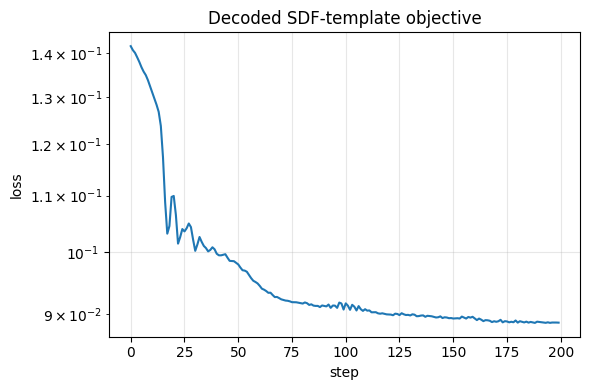

In [19]:
def fit_sdf_template(steps: int = 200, learning_rate: float = 0.03, temperature: float = 1.0):
    angle = torch.nn.Parameter(torch.zeros(1, device=DEVICE))
    dx = torch.nn.Parameter(torch.zeros(1, device=DEVICE))
    dy = torch.nn.Parameter(torch.zeros(1, device=DEVICE))
    optimizer = torch.optim.Adam([angle, dx, dy], lr=learning_rate)
    history = {"loss": [], "grad_norm": [], "angle": [], "dx": [], "dy": []}

    for _ in range(steps):
        optimizer.zero_grad()
        warped_sdf = transformer(
            template_sdf,
            TransformSpec(rigid=RigidParams(angle=angle, dx=dx, dy=dy)),
        ).warped_template
        loss = functional.mse_loss(
            torch.sigmoid(-warped_sdf / temperature),
            target_mask[:, 1:],
        )
        loss.backward()
        history["loss"].append(loss.detach().item())
        history["grad_norm"].append(
            torch.linalg.vector_norm(
                torch.stack([angle.grad.norm(), dx.grad.norm(), dy.grad.norm()])
            ).item()
        )
        optimizer.step()
        for name, parameter in (("angle", angle), ("dx", dx), ("dy", dy)):
            history[name].append(parameter.detach().item())
    return history


sdf_template_run = fit_sdf_template()
print(
    f"decoded SDF-template: loss {sdf_template_run['loss'][0]:.6g} -> "
    f"{sdf_template_run['loss'][-1]:.6g}; "
    f"grad norm at step 0: {sdf_template_run['grad_norm'][0]:.6g}; "
    f"params: angle={sdf_template_run['angle'][-1]:.3f}, "
    f"dx={sdf_template_run['dx'][-1]:.3f}, dy={sdf_template_run['dy'][-1]:.3f}"
 )
plt.figure(figsize=(6, 4))
plt.semilogy(sdf_template_run["loss"])
plt.title("Decoded SDF-template objective")
plt.xlabel("step")
plt.ylabel("loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()

In [20]:
import importlib
import constraints.computers.loss_terms as loss_terms

importlib.reload(loss_terms)
corrected_sdf_template_loss = loss_terms.RegistrationMSE_SDFTEMPLATETerm()(
    LossInput(
        warped_template_sdf=known_template_sdf,
        gt_mask=target_mask,
    )
 )
print(f"corrected SDF-template MSE at stored transform: {corrected_sdf_template_loss.item():.6g}")

corrected SDF-template MSE at stored transform: 0.0723231
